In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import time
import threading

In [2]:
path = "C:\\Program Files\\MetaTrader 5\\terminal64.exe"
login = 5030595537
password = "-r7lRdVn"
server = "MetaQuotes-Demo"
timeout = 10000
portable = False
if mt5.initialize(path=path, login=login, password=password, server=server, timeout=timeout, portable=portable):
    print("Initialization successful")
else:
    print("Initialization not successful")

Initialization successful


In [3]:
symbol = "EURUSD"

timeframe = mt5.TIMEFRAME_H1
from datetime import datetime

import pytz

end_time = datetime.today().astimezone(pytz.utc)

eurusd_rates = mt5.copy_rates_from(symbol, timeframe, end_time, 10000)

In [7]:
data = pd.DataFrame(eurusd_rates)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         10000 non-null  int64  
 1   open         10000 non-null  float64
 2   high         10000 non-null  float64
 3   low          10000 non-null  float64
 4   close        10000 non-null  float64
 5   tick_volume  10000 non-null  uint64 
 6   spread       10000 non-null  int32  
 7   real_volume  10000 non-null  uint64 
dtypes: float64(4), int32(1), int64(1), uint64(2)
memory usage: 586.1 KB


In [ ]:
data.to_csv('EURUSD_10000.csv', index=False)

In [8]:
data['time'] = pd.to_datetime(data['time'], unit='s').dt.tz_localize('UTC')

In [10]:
data.tail()

,time,open,high,low,close,tick_volume,spread,real_volume
9995,2024-12-10 04:00:00+00:00,1.05529,1.05613,1.05515,1.05532,1673,4,0
9996,2024-12-10 05:00:00+00:00,1.05532,1.05576,1.05489,1.05564,1472,4,0
9997,2024-12-10 06:00:00+00:00,1.05564,1.05598,1.05560,1.05574,1129,4,0
9998,2024-12-10 07:00:00+00:00,1.05576,1.05625,1.05540,1.05619,1195,4,0
9999,2024-12-10 08:00:00+00:00,1.05618,1.05680,1.05608,1.05665,1354,4,0


In [6]:

rates = mt5.copy_rates_from(symbol, timeframe, 1000)
print(rates)
da = pd.DataFrame(rates)

None


In [15]:
da.head()

""


In [2]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import time
import threading
from datetime import datetime
import pytz

class SVMTradingBot:
    def __init__(self, account, password, server, model_path, symbol="EURUSD", timeframe=mt5.TIMEFRAME_H1):
        print("Initializing SVMTradingBot...")
        self.account = account
        self.password = password
        self.server = server
        self.model_path = model_path
        self.symbol = symbol
        self.timeframe = timeframe
        self.scaler = StandardScaler()
        self.model = joblib.load(model_path)
        self.running = False
        
        # Initialize and connect to MetaTrader 5
        print("Connecting to MetaTrader 5...")
        if not mt5.initialize():
            print("initialize() failed, error code =", mt5.last_error())
            quit()

        authorized = mt5.login(self.account, password=self.password, server=self.server)
        if not authorized:
            print("Failed to connect to account. Error:", mt5.last_error())
            quit()
        print("Connected to MetaTrader 5")

    def fetch_data(self):
        print("Fetching data...")
        end_time = datetime.today().astimezone(pytz.utc)
        rates = mt5.copy_rates_from(self.symbol, self.timeframe, end_time, 10000)
        
        # Check if rates data is fetched successfully
        if rates is None:
            print("Failed to fetch data. Error:", mt5.last_error())
            return pd.DataFrame()  # Return an empty DataFrame to avoid further errors

        data = pd.DataFrame(rates)
        print("Data fetched successfully. DataFrame shape:", data.shape)
        print(data.head())  # Print the first few rows of the DataFrame to check its structure
        
        data['time'] = pd.to_datetime(data['time'], unit='s')
        data.set_index('time', inplace=True)
        return data

    def calculate_features(self, data):
        print("Calculating features...")
        data['Returns'] = data['close'].pct_change()
        data['SMA_5'] = data['close'].rolling(window=5).mean()
        data['SMA_10'] = data['close'].rolling(window=10).mean()
        data['SMA_20'] = data['close'].rolling(window=20).mean()
        data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
        data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
        data['Momentum'] = data['close'] - data['close'].shift(5)
        data['Volatility'] = data['Returns'].rolling(window=5).std()
        data['ROC_5'] = data['close'].pct_change(periods=5)
        data['Price_Change'] = data['close'].pct_change()
        data['Lag_1'] = data['close'].shift(1)
        data['RSI'] = 100 - (100 / (1 + data['Returns'].rolling(window=14).mean() /
                                     abs(data['Returns'].rolling(window=14).mean())))
        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)
        print("Features calculated successfully")
        return data

    def make_predictions(self, data):
        print("Making predictions...")
        X = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility', 'ROC_5', 'Price_Change', 'Lag_1', 'RSI']]
        X_scaled = self.scaler.fit_transform(X)
        y_pred = self.model.predict(X_scaled)
        data['Predicted_Signal'] = y_pred
        print("Predictions made successfully")
        return data

    def place_order(self, order_type, volume, price, stop_loss, take_profit):
        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": self.symbol,
            "volume": volume,
            "type": order_type,
            "price": price,
            "sl": stop_loss,
            "tp": take_profit,
            "deviation": 10,
            "magic": 234000,
            "comment": "SVMTradingBot order",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_IOC,
        }
        result = mt5.order_send(request)
        return result

    def close_order(self, ticket):
        position = mt5.positions_get(ticket=ticket)
        if not position:
            print(f"Position with ticket {ticket} not found")
            return None

        order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY
        price = mt5.symbol_info_tick(self.symbol).bid if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(self.symbol).ask

        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": self.symbol,
            "volume": position[0].volume,
            "type": order_type,
            "price": price,
            "deviation": 10,
            "magic": 234000,
            "comment": "SVMTradingBot close",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_IOC,
            "position": ticket
        }

        result = mt5.order_send(request)
        if result.retcode != mt5.TRADE_RETCODE_DONE:
            print(f"Close order failed, retcode={result.retcode}")
            result_dict = result._asdict()
            for field in result_dict.keys():
                print("   {}={}".format(field, result_dict[field]))
        else:
            print(f"Order closed successfully, order ID: {result.order}")

        return result

    def execute_trade(self, prediction):
        print("Executing trade...")
        lot = 0.1
        current_positions = mt5.positions_get(symbol=self.symbol)
        current_position_type = current_positions[0].type if current_positions else None

        if prediction == 1:
            price = mt5.symbol_info_tick(self.symbol).ask
            stop_loss = price - 0.01
            take_profit = price + 0.01
            if not current_positions or current_position_type == mt5.ORDER_TYPE_SELL:
                if current_position_type == mt5.ORDER_TYPE_SELL:
                    self.close_order(current_positions[0].ticket)
                result = self.place_order(mt5.ORDER_TYPE_BUY, lot, price, stop_loss, take_profit)
                print("Buy order result:", result)
        elif prediction == 0:
            price = mt5.symbol_info_tick(self.symbol).bid
            stop_loss = price + 0.01
            take_profit = price - 0.01
            if not current_positions or current_position_type == mt5.ORDER_TYPE_BUY:
                if current_position_type == mt5.ORDER_TYPE_BUY:
                    self.close_order(current_positions[0].ticket)
                result = self.place_order(mt5.ORDER_TYPE_SELL, lot, price, stop_loss, take_profit)
                print("Sell order result:", result)
        print("Trade executed")

    def trade(self):
        print("Starting trading loop...")
        self.running = True
        while self.running:
            print("Trading iteration started")
            data = self.fetch_data()
            if data.empty:
                print("No data fetched, skipping this iteration.")
                time.sleep(30)
                continue
            data = self.calculate_features(data)
            data = self.make_predictions(data)
            latest_prediction = data['Predicted_Signal'].iloc[-1]
            print("Latest prediction:", latest_prediction)
            self.execute_trade(latest_prediction)
            print("Sleeping for 1 hour")
            time.sleep(30)  # Sleep for 1 hour (adjust as needed)
            print("Woke up, starting next iteration")

    def start(self):
        print("Starting bot...")
        self.thread = threading.Thread(target=self.trade)
        self.thread.start()

    def stop(self):
        print("Stopping bot...")
        self.running = False
        self.thread.join()
        print("Bot stopped")

# Example usage:
if __name__ == "__main__":
    bot = SVMTradingBot(
        account=5030595537,
        password="-r7lRdVn",
        server="MetaQuotes-Demo",
        model_path="../models/svm_model.pkl"
    )
    bot.start()

    # Run for a certain period or based on a condition
    time.sleep(300)  # Run for 5 minutes
    bot.stop()


Initializing SVMTradingBot...
Connecting to MetaTrader 5...
Connected to MetaTrader 5
Starting bot...
Starting trading loop...
Trading iteration started
Fetching data...
Data fetched successfully. DataFrame shape: (10000, 8)
         time     open     high      low    close  tick_volume  spread  \
0  1683082800  1.10108  1.10206  1.10049  1.10173         1254       0   
1  1683086400  1.10174  1.10242  1.10129  1.10228         1523       0   
2  1683090000  1.10228  1.10258  1.10197  1.10253         1189       0   
3  1683093600  1.10253  1.10299  1.10251  1.10295          805       0   
4  1683097200  1.10295  1.10296  1.10214  1.10218         1156       0   

   real_volume  
0            0  
1            0  
2            0  
3            0  
4            0  
Calculating features...
Features calculated successfully
Making predictions...
Predictions made successfully
Latest prediction: 1.05711
Executing trade...
Trade executed
Sleeping for 1 hour
Woke up, starting next iteration
Tradi

In [63]:
# import MetaTrader5 as mt5
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
# import joblib
# from datetime import datetime, timedelta
# import pytz

# # Initialize and connect to MetaTrader 5
# if not mt5.initialize():
#     print("initialize() failed, error code =", mt5.last_error())
#     quit()

# account = 5030595537
# password = "-r7lRdVn"
# server = "MetaQuotes-Demo"

# authorized = mt5.login(account, password=password, server=server)
# if not authorized:
#     print("Failed to connect to account. Error:", mt5.last_error())
#     quit()

# print("Connected to MetaTrader 5")

# # Parameters
# symbol = "EURUSD"
# timeframe = mt5.TIMEFRAME_M1
# model_path = "../models/svm_model.pkl"
# day_to_backtest = "2023-12-01"  # Change this to the specific day you want to backtest

# # Load the SVM model
# model = joblib.load(model_path)

# # Define the date range
# start_date = datetime.strptime(day_to_backtest, "%Y-%m-%d")
# end_date = start_date + timedelta(days=1)

# # Convert to UTC
# start_date = start_date.astimezone(pytz.utc)
# end_date = end_date.astimezone(pytz.utc)

# # Fetch data
# print("Fetching data...")
# rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_date)
# if rates is None:
#     print("Failed to fetch data. Error:", mt5.last_error())
#     quit()

# data = pd.DataFrame(rates)
# data['time'] = pd.to_datetime(data['time'], unit='s')
# data.set_index('time', inplace=True)

# # Feature calculation
# def calculate_features(data):
#     data['Returns'] = data['close'].pct_change()
#     data['SMA_5'] = data['close'].rolling(window=5).mean()
#     data['SMA_10'] = data['close'].rolling(window=10).mean()
#     data['SMA_20'] = data['close'].rolling(window=20).mean()
#     data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
#     data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
#     data['Momentum'] = data['close'] - data['close'].shift(5)
#     data['Volatility'] = data['Returns'].rolling(window=5).std()
#     data['ROC_5'] = data['close'].pct_change(periods=5)
#     data['Price_Change'] = data['close'].pct_change()
#     data['Lag_1'] = data['close'].shift(1)
#     data['RSI'] = 100 - (100 / (1 + data['Returns'].rolling(window=14).mean() / abs(data['Returns'].rolling(window=14).mean())))
#     data.replace([np.inf, -np.inf], np.nan, inplace=True)
#     data.dropna(inplace=True)
#     return data

# data = calculate_features(data)

# # Prepare the data for prediction
# X = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility', 'ROC_5', 'Price_Change', 'Lag_1', 'RSI']]

# # Fit and transform the scaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Make predictions
# data['Predicted_Signal'] = model.predict(X_scaled)

# # Assuming you have actual signals to compare, you can replace the following with your actual signals
# # For demonstration, let's create a random actual signal
# np.random.seed(42)
# data['Actual_Signal'] = np.random.choice([0, 1], size=len(data))

# # Evaluate the model's performance
# print("Model Performance:")
# print(classification_report(data['Actual_Signal'], data['Predicted_Signal']))

# # Disconnect from MetaTrader 5
# mt5.shutdown()


,return,pred,label,won,pnl,equity,time
28412,0.00008,0,1.0,False,-0.008,2.870,2024-12-04 05:17:00
28413,-0.00012,0,0.0,True,0.012,2.882,2024-12-04 05:18:00
28414,-0.00003,1,0.0,False,-0.003,2.879,2024-12-04 05:19:00
28415,0.00001,0,1.0,False,-0.001,2.878,2024-12-04 05:20:00
28416,-0.00006,0,0.0,True,0.006,2.884,2024-12-04 05:21:00


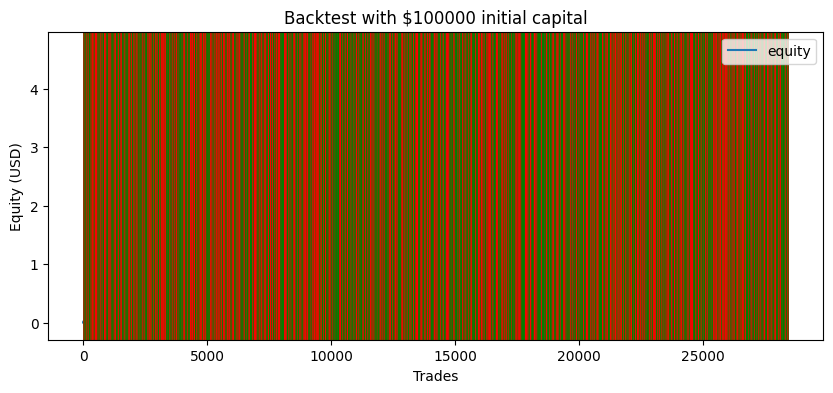

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

# Load the model from the file
loaded_model = load('nexo_xgb.joblib')

# Load the new testing dataset
new_test_data = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')

# Preprocess the new test data to match the training data preprocessing steps

# Normalize 'Adj Close' value
new_test_data['Adj Close'] = new_test_data['close']
new_test_data['return'] = new_test_data['Adj Close'] - new_test_data['Adj Close'].shift(1)
return_range = new_test_data['return'].max() - new_test_data['return'].min()
new_test_data['return'] = new_test_data['return'] / return_range

# Make label (1 as rising price, 0 as falling price)
new_test_data['label'] = new_test_data['return'].shift(-1)
new_test_data['label'] = new_test_data['label'].apply(lambda x: 1 if x > 0.0 else 0)
new_test_data.dropna(inplace=True)

# Extract features and labels for the test set
n_features = 60  # number of features

test_x = np.array([]).reshape([-1, n_features])
test_y = np.array([]).reshape([-1, 1])
trade_times =[]

for index, row in new_test_data.iterrows():
    i = new_test_data.index.get_loc(index)
    if i < n_features:
        continue

    _x = np.array(new_test_data[i - n_features + 1:i + 1]['return']).T.reshape([1, -1])
    _y = new_test_data.iloc[i]['label']
    test_x = np.vstack((test_x, _x))
    test_y = np.vstack((test_y, _y))
    
    # Store the corresponding time for the trade
    trade_times.append(new_test_data.iloc[i]['time'])

test_y = test_y.reshape([-1])

# Make predictions with the loaded model
predictions = loaded_model.predict(test_x)

# Parameters
trade_amount = 100.0
commission = 0.0
stop_loss = 0.02  # Example stop-loss at 2%
take_profit = 0.05  # Example take-profit at 5%

# DataFrame to store trade data
df_trade = pd.DataFrame(test_x[:, -1], columns=['return'])
df_trade['pred'] = predictions
df_trade['label'] = test_y
df_trade['won'] = df_trade['label'] == df_trade['pred']
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade) - 1], inplace=True)

def calc_profit(row):
    trade_return = row['return']
    
    # Apply stop-loss
    if trade_return <= -stop_loss:
        pnl = -stop_loss * trade_amount - commission
    # Apply take-profit
    elif trade_return >= take_profit:
        pnl = take_profit * trade_amount - commission
    else:
        # Regular calculation
        if row['won']:
            pnl = abs(trade_return) * trade_amount - commission
        else:
            pnl = -abs(trade_return) * trade_amount - commission
    
    return pnl

# Calculate profit and equity
df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()
# Ensure the lengths of trade_times and df_trade match
trade_times = trade_times[:len(df_trade)]  # Trim trade_times if it has extra elements
df_trade['time'] = trade_times  # Add the time of trade execution

# Display the last few rows of the DataFrame
display(df_trade.tail())

# Plot equity curve
df_trade.plot(y='equity', figsize=(10, 4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')

# Highlight trades on the plot
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

plt.show()


Net Profit            : $2.88
Total win volume      : 148
Total loss volume     : -145
Number Winning Trades : 13264
Number Losing Trades  : 13270
Percent Profitable    : 49.99%
Avg Win Trade         : $0.011
Avg Los Trade         : $-0.011
Largest Win Trade     : $0.385
Largest Los Trade     : $-0.619
Profit Factor         : 1.02


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9320\2939523137.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


<Axes: >

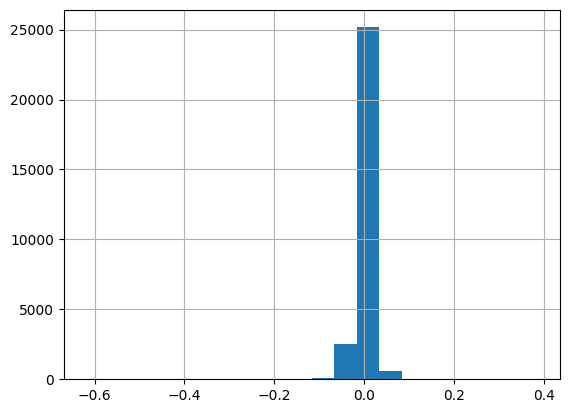

In [46]:
# Calculate summary of trades
n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
win_vol = df_trade[df_trade['pnl']>0.0]['pnl'].mean() * n_win_trades
loss_vol = df_trade[df_trade['pnl']<0.0]['pnl'].mean() * n_los_trades
# risk_exposure = df_trade['risk'].sum()
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
# print("Risk Exposure         : %d" % risk_exposure)
print("Total win volume      : %d" % win_vol)
print("Total loss volume     : %d" % loss_vol)
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

In [25]:
df_trade.head()

,return,pred,label,won,pnl,equity
0,0.00000,0,0.0,True,0.000,0.000
1,-0.00011,0,0.0,True,0.011,0.011
2,0.00006,1,1.0,True,0.006,0.017
3,-0.00001,0,0.0,True,0.001,0.018
4,0.00001,0,1.0,False,-0.001,0.017


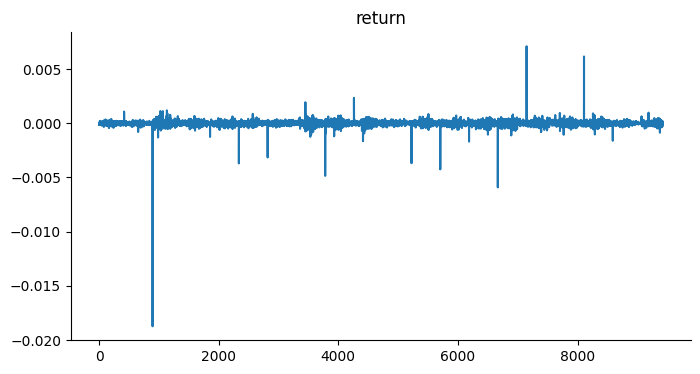

In [37]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='line', figsize=(8, 4), title='return')
plt.gca().spines[['top', 'right']].set_visible(False)

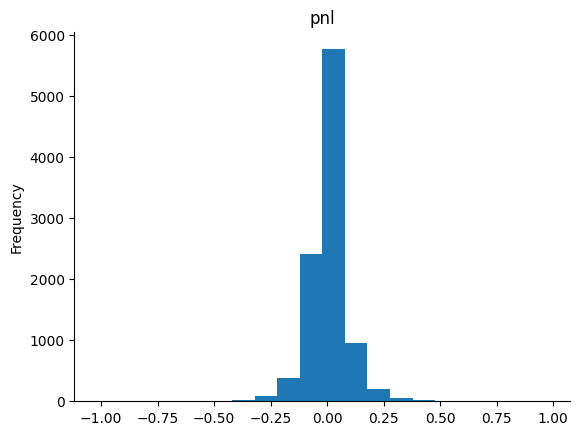

In [16]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='hist', bins=20, title='pnl')
plt.gca().spines[['top', 'right',]].set_visible(False)

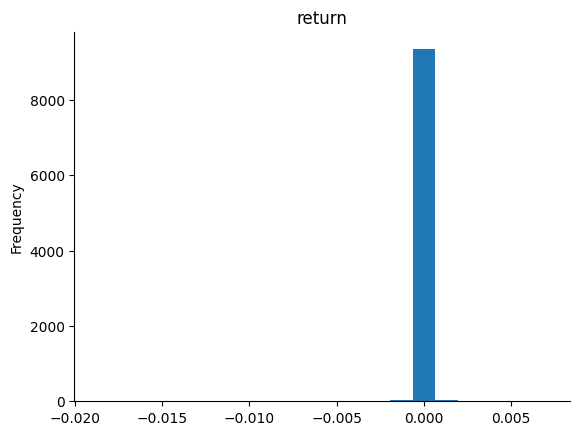

In [36]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='hist', bins=20, title='return')
plt.gca().spines[['top', 'right',]].set_visible(False)

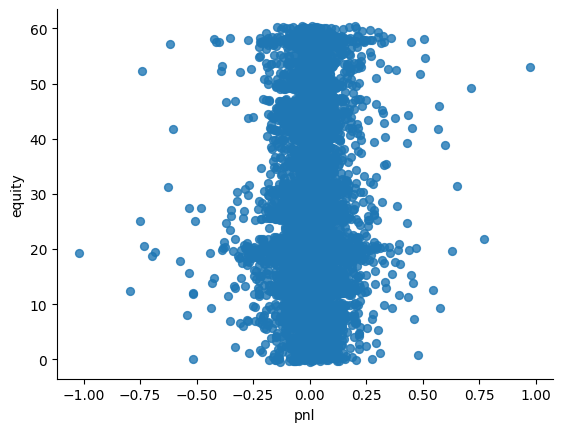

In [18]:
# @title pnl vs equity

from matplotlib import pyplot as plt
df_trade.plot(kind='scatter', x='pnl', y='equity', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

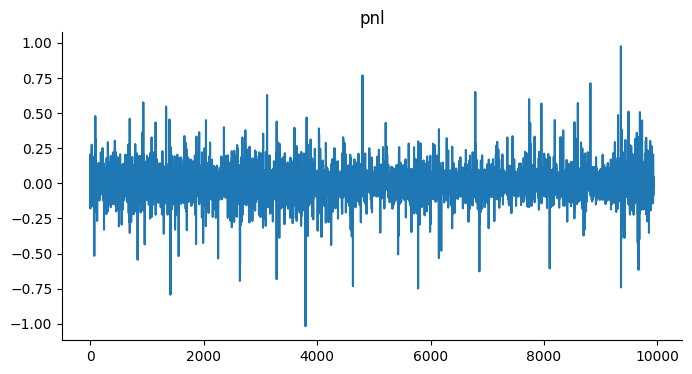

In [19]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='line', figsize=(8, 4), title='pnl')
plt.gca().spines[['top', 'right']].set_visible(False)

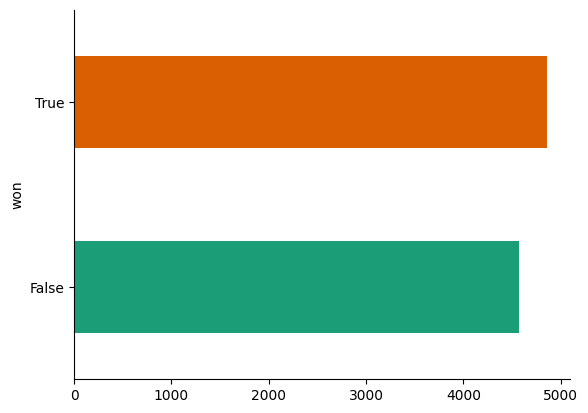

In [35]:
# @title won

from matplotlib import pyplot as plt
import seaborn as sns
df_trade.groupby('won').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

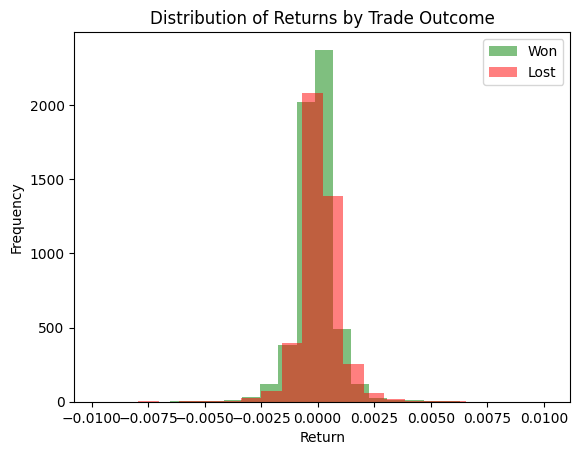

In [21]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['return'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['return'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of Returns by Trade Outcome')
_ = plt.legend()

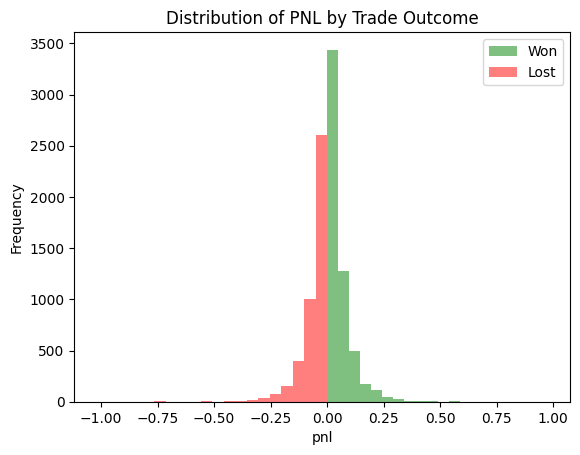

In [22]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['pnl'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['pnl'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('pnl')
plt.ylabel('Frequency')
plt.title('Distribution of PNL by Trade Outcome')
_ = plt.legend()

In [26]:
df = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')
df.head()

,time,open,high,low,close,tick_volume
0,2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29
1,2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28
2,2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25
3,2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15
4,2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16


,return,pred,label,won,time,pnl,equity
9419,0.00009,0,1.0,False,2024-11-29 18:48:00,-0.009,5.310
9420,-0.00028,0,0.0,True,2024-11-29 18:49:00,0.028,5.338
9421,-0.00003,1,0.0,False,2024-11-29 18:50:00,-0.003,5.335
9422,-0.00020,0,0.0,True,2024-11-29 18:51:00,0.020,5.355
9423,0.00015,0,1.0,False,2024-11-29 18:52:00,-0.015,5.340


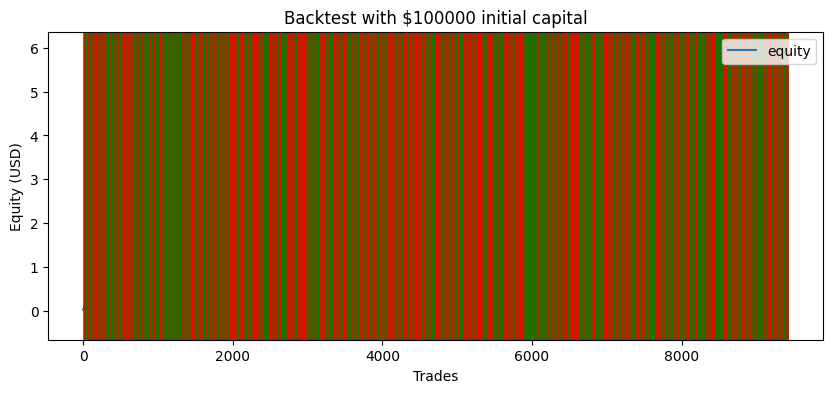

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

# Load the model from the file
loaded_model = load('nexo_xgb.joblib')

# Load the new testing dataset
new_test_data = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')

# Convert 'time' column to datetime
new_test_data['time'] = pd.to_datetime(new_test_data['time'])

# Filter the dataset to only include rows between 1:00 PM and 9:00 PM GMT
new_test_data = new_test_data[(new_test_data['time'].dt.time >= pd.Timestamp('13:00').time()) & 
                              (new_test_data['time'].dt.time <= pd.Timestamp('21:00').time())]

# Preprocess the new test data to match the training data preprocessing steps

# Normalize 'Adj Close' value
new_test_data['Adj Close'] = new_test_data['close']
new_test_data['return'] = new_test_data['Adj Close'] - new_test_data['Adj Close'].shift(1)
return_range = new_test_data['return'].max() - new_test_data['return'].min()
new_test_data['return'] = new_test_data['return'] / return_range

# Make label (1 as rising price, 0 as falling price)
new_test_data['label'] = new_test_data['return'].shift(-1)
new_test_data['label'] = new_test_data['label'].apply(lambda x: 1 if x > 0.0 else 0)
new_test_data.dropna(inplace=True)

# Extract features and labels for the test set
n_features = 60  # number of features

test_x = np.array([]).reshape([-1, n_features])
test_y = np.array([]).reshape([-1, 1])
trade_times = []  # To store the corresponding times for each trade

for index, row in new_test_data.iterrows():
    i = new_test_data.index.get_loc(index)
    if i < n_features:
        continue

    _x = np.array(new_test_data[i - n_features + 1:i + 1]['return']).T.reshape([1, -1])
    _y = new_test_data.iloc[i]['label']
    test_x = np.vstack((test_x, _x))
    test_y = np.vstack((test_y, _y))
    # Store the corresponding time for the trade
    trade_times.append(new_test_data.iloc[i]['time'])

test_y = test_y.reshape([-1])

# Make predictions with the loaded model
predictions = loaded_model.predict(test_x)

# Parameters
trade_amount = 100.0
commission = 0.0
stop_loss = 0.02  # Example stop-loss at 2%
take_profit = 0.05  # Example take-profit at 5%

# DataFrame to store trade data
df_trade = pd.DataFrame(test_x[:, -1], columns=['return'])
df_trade['pred'] = predictions
df_trade['label'] = test_y
df_trade['won'] = df_trade['label'] == df_trade['pred']
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade) - 1], inplace=True)
# Ensure the lengths of trade_times and df_trade match
trade_times = trade_times[:len(df_trade)]  # Trim trade_times if it has extra elements
df_trade['time'] = trade_times  # Add the time of trade execution

def calc_profit(row):
    trade_return = row['return']
    
    # Apply stop-loss
    if trade_return <= -stop_loss:
        pnl = -stop_loss * trade_amount - commission
    # Apply take-profit
    elif trade_return >= take_profit:
        pnl = take_profit * trade_amount - commission
    else:
        # Regular calculation
        if row['won']:
            pnl = abs(trade_return) * trade_amount - commission
        else:
            pnl = -abs(trade_return) * trade_amount - commission
    
    return pnl

# Calculate profit and equity
df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()

# Display the last few rows of the DataFrame
display(df_trade.tail())

# Plot equity curve
df_trade.plot(y='equity', figsize=(10, 4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')

# Highlight trades on the plot
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9320\2939523137.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


Net Profit            : $5.34
Total win volume      : 67
Total loss volume     : -62
Number Winning Trades : 4524
Number Losing Trades  : 4542
Percent Profitable    : 49.90%
Avg Win Trade         : $0.015
Avg Los Trade         : $-0.014
Largest Win Trade     : $1.872
Largest Los Trade     : $-0.710
Profit Factor         : 1.09


<Axes: >

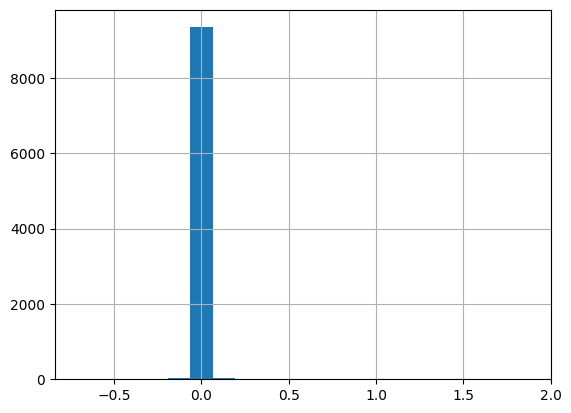

In [34]:
# Calculate summary of trades
n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
win_vol = df_trade[df_trade['pnl']>0.0]['pnl'].mean() * n_win_trades
loss_vol = df_trade[df_trade['pnl']<0.0]['pnl'].mean() * n_los_trades
# risk_exposure = df_trade['risk'].sum()
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
# print("Risk Exposure         : %d" % risk_exposure)
print("Total win volume      : %d" % win_vol)
print("Total loss volume     : %d" % loss_vol)
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

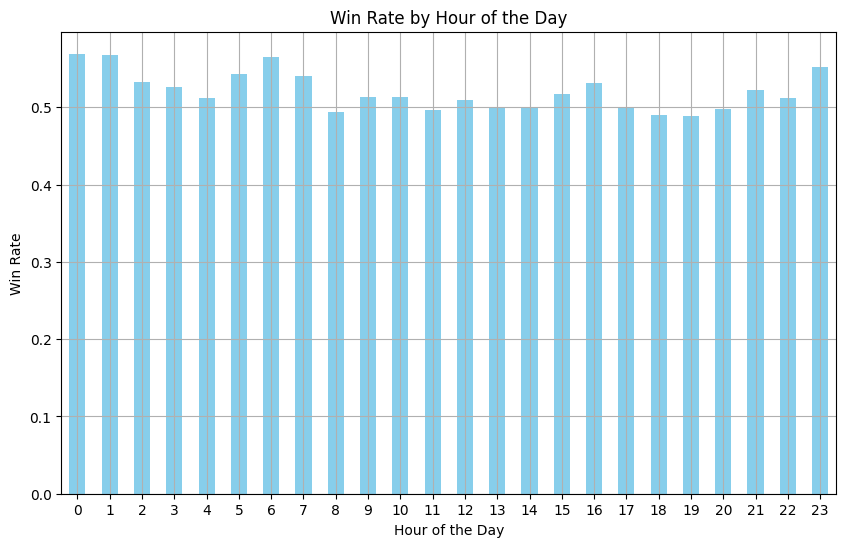

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column (you can adjust to group by other time intervals)
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and calculate the win rate for each hour
hourly_win_rate = df_trade.groupby('hour')['won'].mean()

# Plot the win rate by hour
plt.figure(figsize=(10, 6))
hourly_win_rate.plot(kind='bar', color='skyblue')
plt.title('Win Rate by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# Alternatively, if you want to analyze by specific time intervals (e.g., 30-minute intervals), you can do:
# df_trade['half_hour'] = df_trade['time'].dt.floor('30T')  # This groups by 30-minute intervals
# half_hour_win_rate = df_trade.groupby('half_hour')['won'].mean()

# # Plot the win rate by 30-minute interval
# plt.figure(figsize=(12, 6))
# half_hour_win_rate.plot(kind='bar', color='skyblue')
# plt.title('Win Rate by 30-Minute Interval')
# plt.xlabel('Time Interval')
# plt.ylabel('Win Rate')
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.show()


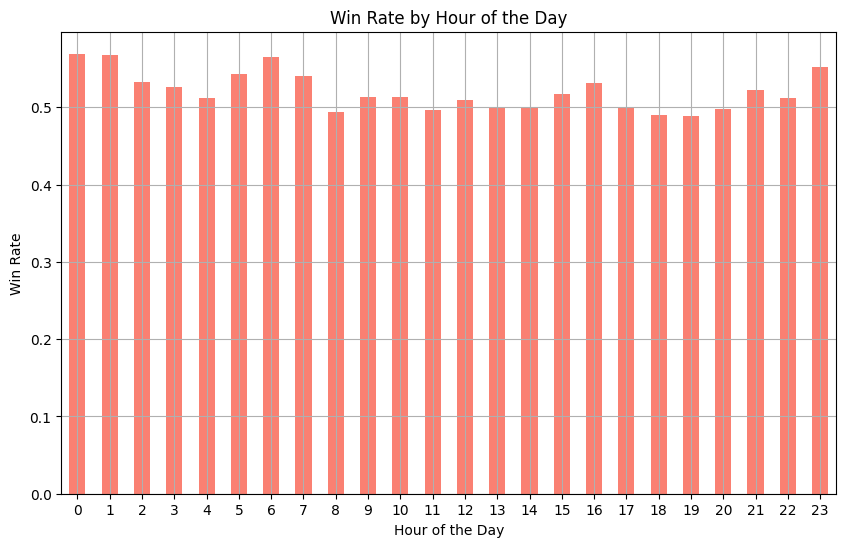

In [50]:
# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column (you can adjust to group by other time intervals)
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and calculate the win rate for each hour
hourly_win_rate = df_trade.groupby('hour')['won'].mean()

# Plot the win rate by hour
plt.figure(figsize=(10, 6))
hourly_win_rate.plot(kind='bar', color='salmon')
plt.title('Win Rate by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

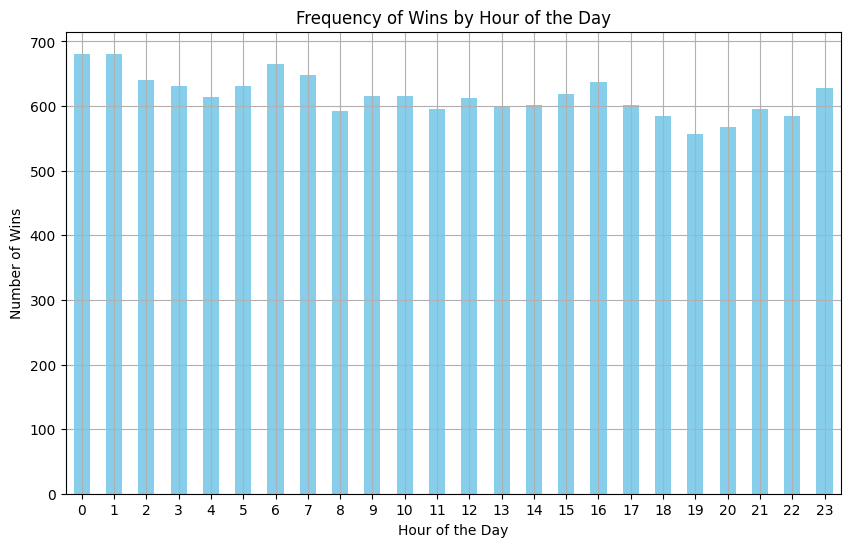

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Count the frequency of wins (won == True) for each hour
hourly_win_count = df_trade[df_trade['won'] == True].groupby('hour').size()

# Plot the frequency of wins by hour
plt.figure(figsize=(10, 6))
hourly_win_count.plot(kind='bar', color='skyblue')
plt.title('Frequency of Wins by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Wins')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


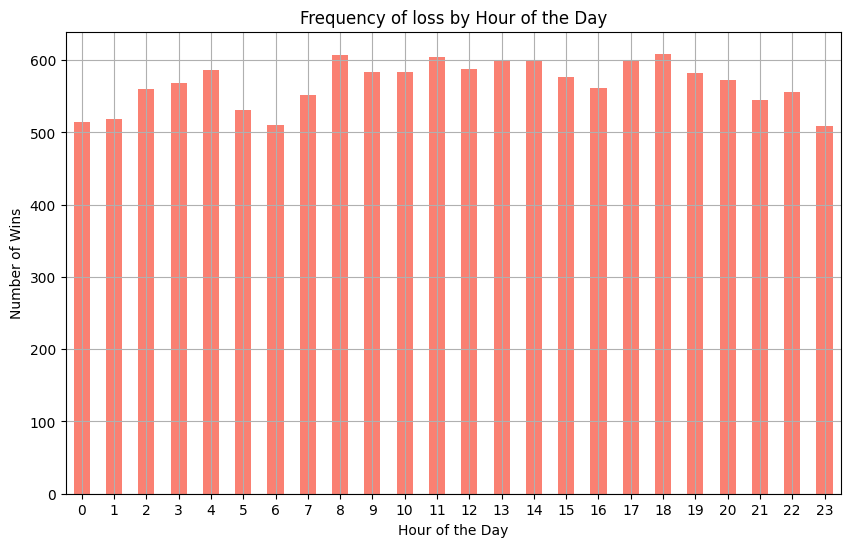

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Count the frequency of wins (won == False) for each hour
hourly_win_count = df_trade[df_trade['won'] == False].groupby('hour').size()

# Plot the frequency of wins by hour
plt.figure(figsize=(10, 6))
hourly_win_count.plot(kind='bar', color='salmon')
plt.title('Frequency of loss by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Wins')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


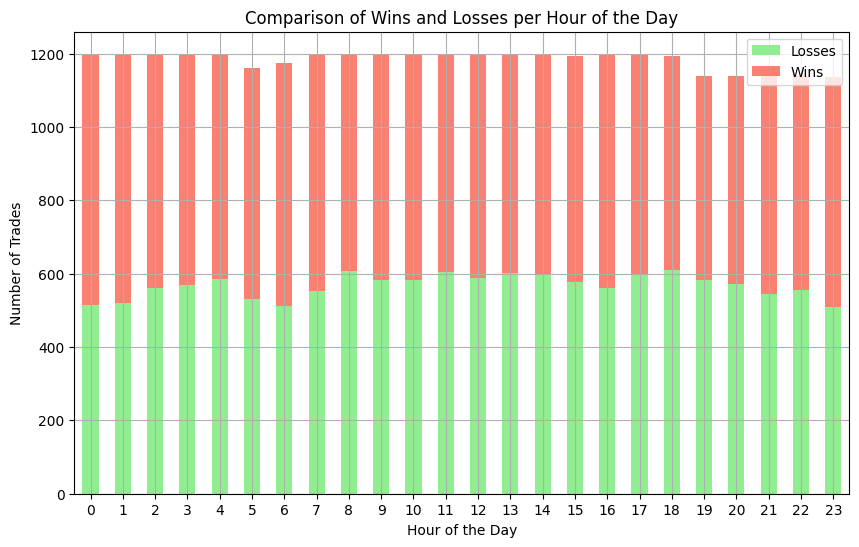

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and count the wins and losses
hourly_win_loss = df_trade.groupby(['hour', 'won']).size().unstack(fill_value=0)

# Plot the comparison of wins and losses per hour
hourly_win_loss.plot(kind='bar', figsize=(10, 6), stacked=True, color=['lightgreen', 'salmon'])
plt.title('Comparison of Wins and Losses per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trades')
plt.xticks(rotation=0)
plt.legend(['Losses', 'Wins'])
plt.grid(True)
plt.show()


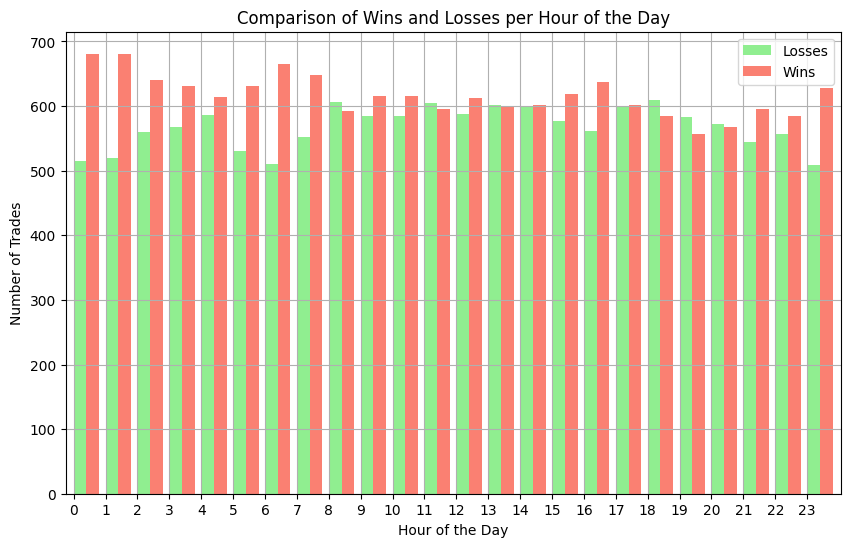

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and count the wins and losses
hourly_win_loss = df_trade.groupby(['hour', 'won']).size().unstack(fill_value=0)

# Plot the comparison of wins and losses per hour side by side
ax = hourly_win_loss.plot(kind='bar', figsize=(10, 6), position=0, width=0.8, color=['lightgreen', 'salmon'])


plt.title('Comparison of Wins and Losses per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trades')
plt.xticks(rotation=0)
plt.legend(['Losses', 'Wins'])
plt.grid(True)
plt.show()


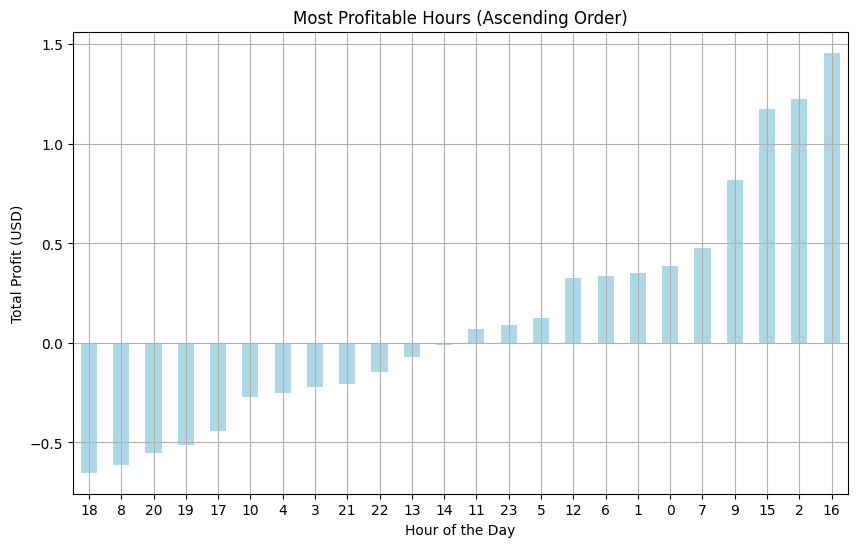

hour
18   -0.652
8    -0.613
20   -0.553
19   -0.511
17   -0.442
10   -0.273
4    -0.252
3    -0.223
21   -0.204
22   -0.148
13   -0.069
14   -0.010
11    0.068
23    0.090
5     0.124
12    0.326
6     0.335
1     0.352
0     0.387
7     0.475
9     0.819
15    1.175
2     1.225
16    1.458
Name: pnl, dtype: float64


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and calculate the total profit for each hour
hourly_profit = df_trade.groupby('hour')['pnl'].sum()

# Sort the hours by profit in ascending order
hourly_profit_sorted = hourly_profit.sort_values(ascending=True)

# Plot the most profitable hours
plt.figure(figsize=(10, 6))
hourly_profit_sorted.plot(kind='bar', color='lightblue')
plt.title('Most Profitable Hours (Ascending Order)')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Profit (USD)')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# Display the sorted hours and their profits
print(hourly_profit_sorted)


In [61]:
import pandas as pd

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Convert 'won' column to int (True=1, False=0)
df_trade['won_int'] = df_trade['won'].astype(int)

# Group by hour and count the number of wins and losses
hourly_counts = df_trade.groupby('hour')['won_int'].value_counts().unstack(fill_value=0)

# Filter hours where wins are greater than losses
hours_with_more_wins = hourly_counts[1] > hourly_counts[0]

# Get the total profit and loss for these hours
df_trade_filtered = df_trade[df_trade['hour'].isin(hours_with_more_wins.index[hours_with_more_wins])]

# Calculate total profit and loss
total_profit = df_trade_filtered[df_trade_filtered['won'] == True]['pnl'].sum()
total_loss = df_trade_filtered[df_trade_filtered['won'] == False]['pnl'].sum()

# Print the results
print(f"Total Profit for hours with more winning trades: {total_profit:.2f}")
print(f"Total Loss for hours with more losing trades: {total_loss:.2f}")


Total Profit for hours with more winning trades: 109.60
Total Loss for hours with more losing trades: -104.39


In [62]:
import pandas as pd

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Convert 'won' column to int (True=1, False=0)
df_trade['won_int'] = df_trade['won'].astype(int)

# Group by hour and count the number of wins and losses
hourly_counts = df_trade.groupby('hour')['won_int'].value_counts().unstack(fill_value=0)

# Filter hours where wins are greater than losses
hours_with_more_wins = hourly_counts[1] > hourly_counts[0]

# Get the total profit and loss for these hours
df_trade_filtered = df_trade[df_trade['hour'].isin(hours_with_more_wins.index[hours_with_more_wins])]

# Calculate total profit and total loss
total_profit = df_trade_filtered[df_trade_filtered['won'] == True]['pnl'].sum()
total_loss = df_trade_filtered[df_trade_filtered['won'] == False]['pnl'].sum()

# Calculate net profit (profit minus loss)
net_profit = total_profit + total_loss  # Since losses are negative, this effectively subtracts them

# Print the results
print(f"Total Profit for hours with more winning trades: {total_profit:.2f}")
print(f"Total Loss for hours with more losing trades: {total_loss:.2f}")
print(f"Net Profit/Loss: {net_profit:.2f}")


Total Profit for hours with more winning trades: 109.60
Total Loss for hours with more losing trades: -104.39
Net Profit/Loss: 5.21
